In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import math

RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Load artifacts exported from 01_data_exploration.ipynb ---
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "NK_cell_dataset").exists():
            return candidate
    raise FileNotFoundError("Projektstamm konnte nicht gefunden werden.")

PROJECT_ROOT = find_project_root(Path.cwd())
ARTIFACT_DIR = PROJECT_ROOT

# --- Load donor-balanced subsample of NK data ---
nk_balanced_raw = pd.read_parquet(ARTIFACT_DIR / "nk_balanced_raw.parquet")
# --- Load full (unsampled) NK data ---
nk_full_raw = pd.read_parquet(ARTIFACT_DIR / "nk_full_raw.parquet")

channel_table = pd.read_parquet(ARTIFACT_DIR / "channel_table.parquet")
labels = pd.read_csv(ARTIFACT_DIR / "labels.csv")

# --- Filter to analysis markers only ---
analysis_markers = channel_table.loc[channel_table["analysis_marker"], "marker_name_pns"].tolist()
meta_cols = ["sample_id", "label", "clinical_group"]
nk_filtered = nk_balanced_raw[meta_cols + analysis_markers].copy()

print(f"Loaded {len(nk_filtered):,} cells × {len(analysis_markers)} markers "
      f"from {nk_filtered['sample_id'].nunique()} donors")

Loaded 40,000 cells × 37 markers from 20 donors


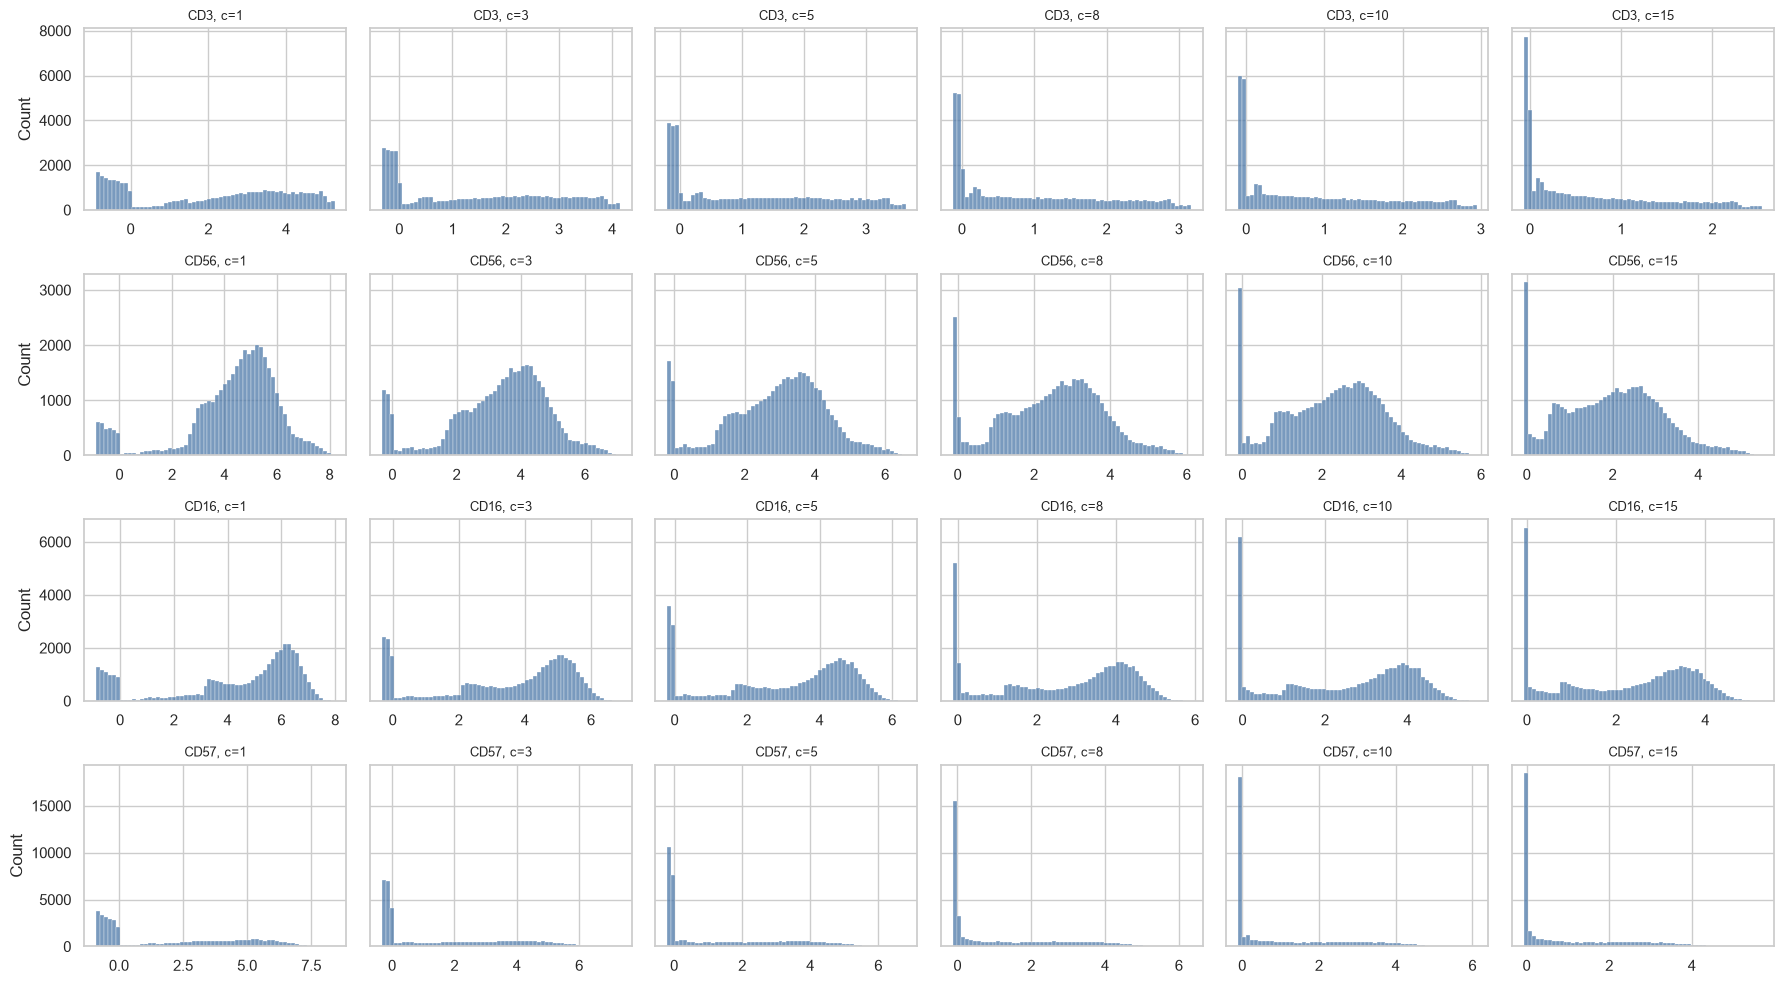

In [3]:
# --- arcsinh cofactor exploration ---
def arcsinh_transform(frame, marker_names, cofactor):
    out = frame.copy()
    out[marker_names] = np.arcsinh(out[marker_names] / cofactor)
    return out

cofactor_candidates = [1, 3, 5, 8, 10, 15]
diagnostic_markers = ["CD3", "CD56", "CD16", "CD57"]  # known bimodal markers

fig, axes = plt.subplots(len(diagnostic_markers), len(cofactor_candidates),
                          figsize=(3 * len(cofactor_candidates), 2.5 * len(diagnostic_markers)),
                          sharey="row")

for row, marker in enumerate(diagnostic_markers):
    for col, cofactor in enumerate(cofactor_candidates):
        transformed = np.arcsinh(nk_filtered[marker] / cofactor)
        sns.histplot(transformed, bins=60, ax=axes[row, col], color="#4c78a8")
        axes[row, col].set_title(f"{marker}, c={cofactor}", fontsize=9)
        axes[row, col].set_xlabel("")

plt.tight_layout()
plt.show()

In [4]:
# --- Apply chosen cofactor + z-score for PCA/t-SNE/UMAP input ---
ARCSINH_COFACTOR = 5.0

nk_transformed = arcsinh_transform(nk_filtered, analysis_markers, ARCSINH_COFACTOR)

# --- Z-score normalization ---
scaler = StandardScaler()
nk_scaled = nk_transformed.copy()
# Apply the scaler to the specified columns
nk_scaled[analysis_markers] = scaler.fit_transform(nk_transformed[analysis_markers])

# Prepare the feature matrix for downstream analysis
X = nk_scaled[analysis_markers].to_numpy()
sample_ids = nk_scaled["sample_id"].to_numpy()
clinical_group = nk_scaled["clinical_group"].to_numpy()

print(f"Feature matrix ready: X.shape = {X.shape}")
display(nk_scaled.head())

Feature matrix ready: X.shape = (40000, 37)


,sample_id,label,clinical_group,CD3,CD27,CD19,CD4,CD8,CD57,2DL1-S1,...,CD94,CD34,CCR7,2DL3,NKG2A,HLA-DR,2DL4,CD56,2DL5,CD25
0,a_001,1,CMV+,-0.970905,-0.606723,-0.603757,-0.518787,0.408722,1.262401,-0.637691,...,-0.660154,-0.590707,-0.278266,-0.601411,0.823392,0.193011,1.498108,-0.237036,-0.737142,-0.253715
1,a_001,1,CMV+,0.380514,-0.765951,-0.537882,-0.469332,-0.665763,-0.869966,0.252270,...,-1.368312,-0.683341,-0.356010,2.327783,-0.991975,0.312983,-0.194853,-0.329703,-0.687247,-0.474097
2,a_001,1,CMV+,-0.742688,0.897181,0.694621,-0.482967,0.630869,1.184771,-0.675650,...,-1.012467,-0.719988,-0.497955,-0.539528,-0.747228,-1.364530,-0.724681,0.127341,-0.538723,-0.559586
3,a_001,1,CMV+,-0.518125,-0.620518,-0.494963,-0.552950,0.128876,-0.877883,-0.632458,...,0.925268,-0.523634,-0.426150,0.670718,1.328362,0.174369,-0.761817,-1.051555,-0.613813,-0.433535
4,a_001,1,CMV+,-0.998702,1.391164,-0.127265,-0.264165,-0.761708,1.263926,0.287416,...,-0.194036,0.457053,1.736379,-0.479299,0.630355,0.818920,-0.536806,-1.076981,-0.198778,-0.189867


## Setting up AnnData

In [5]:
import anndata as ad
import scanpy as sc

sc.settings.verbosity = 1

# nk_transformed = arcsinh(c=5)-transformed data from the previous step, NOT yet z-scored
obs = nk_transformed[["sample_id", "label", "clinical_group"]].reset_index(drop=True)
X_arcsinh = nk_transformed[analysis_markers].to_numpy()

adata = ad.AnnData(
    X=X_arcsinh,
    obs=obs,
    var=pd.DataFrame(index=analysis_markers),
)
adata.layers["arcsinh"] = adata.X.copy()  # keep a snapshot before scaling

print(adata)

AnnData object with n_obs × n_vars = 40000 × 37
    obs: 'sample_id', 'label', 'clinical_group'
    layers: None (.X), 'arcsinh'


c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


### Investigating near-zero-variance markers 
since noisy dimensions inflate the denominator and can flatten the explained variance curve further.

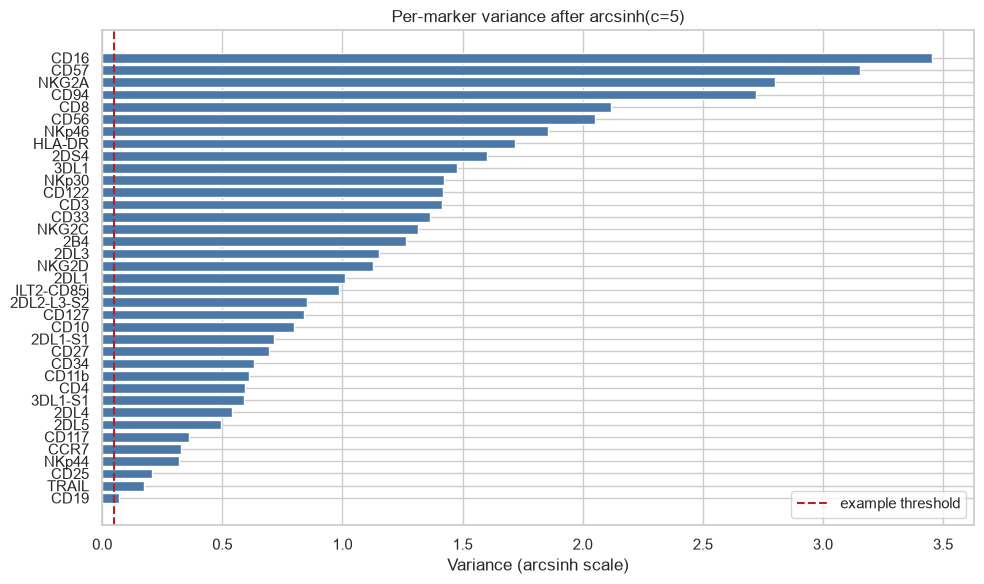

,variance
CD19,0.070028
TRAIL,0.173690
CD25,0.209308
NKp44,0.320738
CCR7,0.328321
CD117,0.360785
2DL5,0.495571
2DL4,0.541105
3DL1-S1,0.588375
CD4,0.594914


In [6]:
# Detecting and filtering near-zero-variance markers
marker_variance = pd.Series(
    adata.layers["arcsinh"].var(axis=0), index=adata.var_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(marker_variance.index, marker_variance.values, color="#4c78a8")
ax.axvline(0.05, color="firebrick", linestyle="--", label="example threshold")
ax.set(xlabel="Variance (arcsinh scale)", title="Per-marker variance after arcsinh(c=5)")
ax.legend()
plt.tight_layout()
plt.show()

marker_variance.to_frame("variance")

In [7]:
LOW_VARIANCE_THRESHOLD = 0.05  # inspect the plot and adjust

low_variance_markers = marker_variance[marker_variance < LOW_VARIANCE_THRESHOLD].index.tolist()
print(f"Flagged as low-variance ({len(low_variance_markers)}): {low_variance_markers}")

# Only drop after checking these aren't biologically meaningful "always-on/off" markers
kept_markers = [m for m in analysis_markers if m not in low_variance_markers]
adata = adata[:, kept_markers].copy()
print(f"Retained {adata.n_vars} markers for PCA")

Flagged as low-variance (0): []
Retained 37 markers for PCA


In [8]:
# sc.pp.scale z-scores each marker (mean 0, unit variance) and stores mean/std in adata.var
sc.pp.scale(adata, max_value=None)  # set e.g. max_value=10 if you want outlier clipping
adata.layers["scaled"] = adata.X.copy()

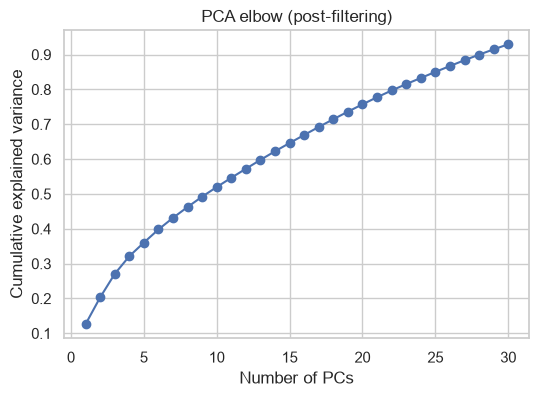

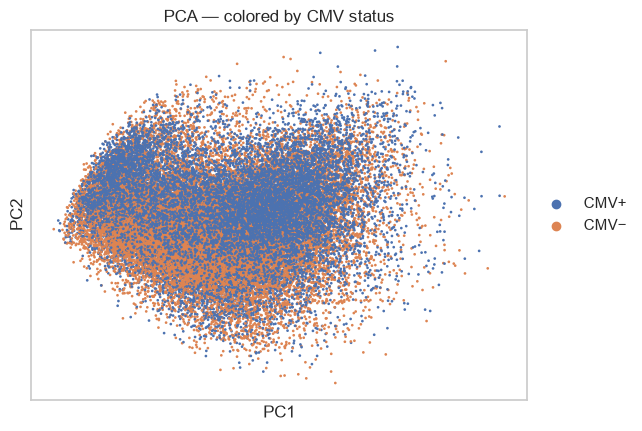

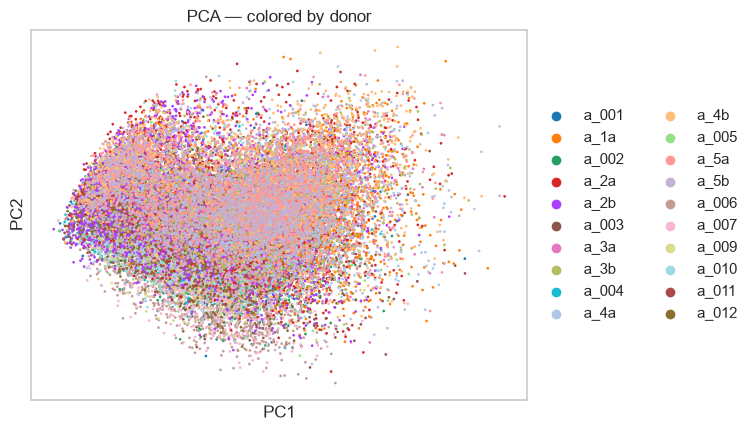

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


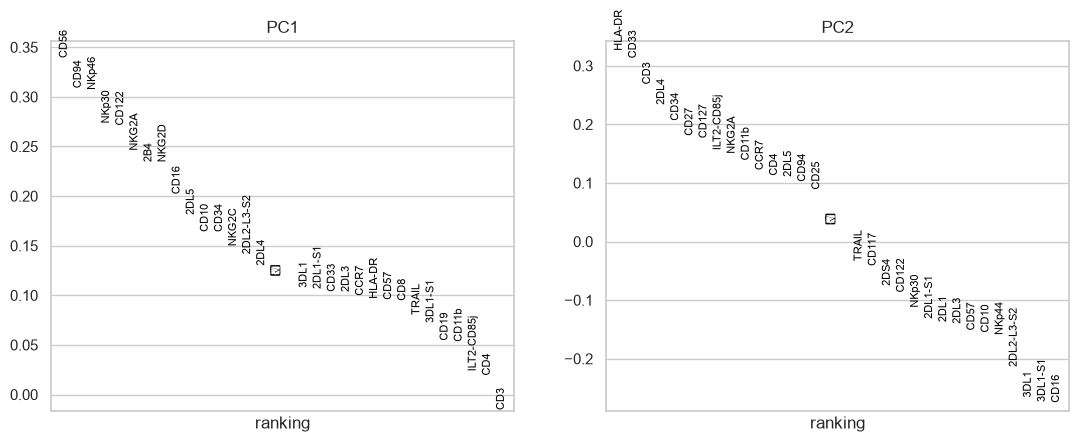

In [9]:
# Re-run PCA on the filtered, scaled data
sc.tl.pca(adata, n_comps=30, svd_solver="arpack", random_state=RANDOM_SEED)
X_pca = np.asarray(adata.obsm["X_pca"], dtype=np.float32)

# Plot the elbow without noisy markers
cumulative_var = np.cumsum(adata.uns["pca"]["variance_ratio"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(cumulative_var) + 1), cumulative_var, marker="o")
ax.set(xlabel="Number of PCs", ylabel="Cumulative explained variance", title="PCA elbow (post-filtering)")
plt.show()

# Colored by CMV clinical group
sc.pl.pca(
    adata, color="clinical_group", dimensions=(0, 1),
    title="PCA — colored by CMV status", size=15,
)

# Colored by donor, to check for donor-driven structure/batch effects
sc.pl.pca(
    adata, color="sample_id", dimensions=(0, 1),
    title="PCA — colored by donor", size=15,
)

# Per-marker loadings on the first two PCs — useful for interpreting what PC1/PC2 represent
sc.pl.pca_loadings(adata, components=[1, 2])

In [10]:
# Reconstruction error for a given number of components
pca_k = PCA(n_components=20, random_state=RANDOM_SEED)
X_pca_k = pca_k.fit_transform(X)
X_reconstructed = pca_k.inverse_transform(X_pca_k)

mse_per_marker = np.mean((X - X_reconstructed) ** 2, axis=0)
total_mse = np.mean((X - X_reconstructed) ** 2)

print(f"Total reconstruction MSE with {pca_k.n_components_} PCs: {total_mse:.4f}")
print(f"Cumulative explained variance: {pca_k.explained_variance_ratio_.sum():.2%}")
# Since X is z-scored (total variance = 1 per marker, 37 total),
# total_mse should be ≈ 37 * (1 - cumulative_explained_variance) / 37 = (1 - cum_var)

Total reconstruction MSE with 20 PCs: 0.2428
Cumulative explained variance: 75.72%


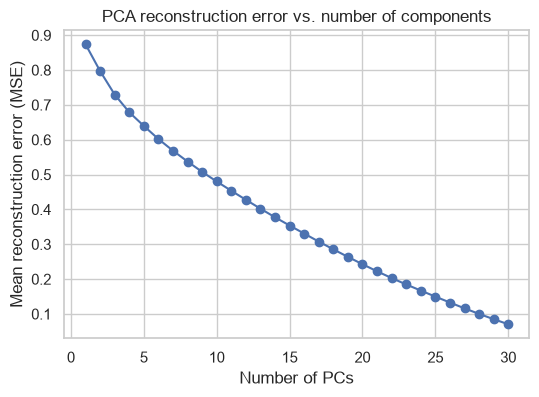

In [11]:
n_components_range = range(1, 31)
recon_errors = []
for k in n_components_range:
    pca_k = PCA(n_components=k, random_state=RANDOM_SEED)
    X_k = pca_k.fit_transform(X)
    X_rec = pca_k.inverse_transform(X_k)
    recon_errors.append(np.mean((X - X_rec) ** 2))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(n_components_range), recon_errors, marker="o")
ax.set(xlabel="Number of PCs", ylabel="Mean reconstruction error (MSE)",
       title="PCA reconstruction error vs. number of components")
plt.show()

In [12]:
from sklearn.manifold import trustworthiness

def knn_preservation(X_high, X_low, k=15):
    """Fraction of each point's k nearest neighbors preserved between high-D and low-D space."""
    from sklearn.neighbors import NearestNeighbors
    nn_high = NearestNeighbors(n_neighbors=k + 1).fit(X_high)
    nn_low = NearestNeighbors(n_neighbors=k + 1).fit(X_low)
    idx_high = nn_high.kneighbors(return_distance=False)[:, 1:]
    idx_low = nn_low.kneighbors(return_distance=False)[:, 1:]
    overlap = [len(set(a) & set(b)) / k for a, b in zip(idx_high, idx_low)]
    return np.mean(overlap)

# Fixed small subsample for fast parameter sweeps
SWEEP_N_CELLS = 5000
sweep_idx = np.sort(np.random.default_rng(RANDOM_SEED).choice(len(X_pca), SWEEP_N_CELLS, replace=False))
X_pca_sweep = X_pca[sweep_idx]

In [13]:
# --- t-SNE on the same fixed subsample ---
# scikit-learn's Barnes-Hut implementation avoids the native openTSNE crash here.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=RANDOM_SEED,
    n_jobs=6,
    max_iter=750,
    method="barnes_hut",
)
X_tsne_cmp = tsne.fit_transform(X_pca)
print(f"t-SNE completed for {len(X_pca):,} cells")

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


t-SNE completed for 40,000 cells


In [15]:
umap_param_grid = [
    {"n_neighbors": nn, "min_dist": md}
    for nn in [5, 15, 30, 50]
    for md in [0.0, 0.1, 0.3, 0.5]
]
# Sweep UMAP parameters on the small subsample to find a good combination of n_neighbors and min_dist
umap_results = []
for params in umap_param_grid:
    reducer = umap.UMAP(random_state=RANDOM_SEED, **params, learning_rate=0.5)
    embedding = reducer.fit_transform(X_pca_sweep)
    # Compute trustworthiness and kNN preservation for this embedding
    score_tw = trustworthiness(X_pca_sweep, embedding, n_neighbors=15)
    score_knn = knn_preservation(X_pca_sweep, embedding, k=15)
    umap_results.append({**params, "trustworthiness": score_tw, "knn_preservation": score_knn,
                          "embedding": embedding})

umap_results_df = pd.DataFrame(umap_results).drop(columns="embedding")
umap_results_df.sort_values("trustworthiness", ascending=False)

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-

,n_neighbors,min_dist,trustworthiness,knn_preservation
0,5,0.0,0.893240,0.171307
4,15,0.0,0.885443,0.155160
1,5,0.1,0.880420,0.159507
12,50,0.0,0.877531,0.135533
8,30,0.0,0.877032,0.142173
5,15,0.1,0.873261,0.140560
9,30,0.1,0.865374,0.127093
13,50,0.1,0.861208,0.120680
2,5,0.3,0.848935,0.128293
6,15,0.3,0.847732,0.111733


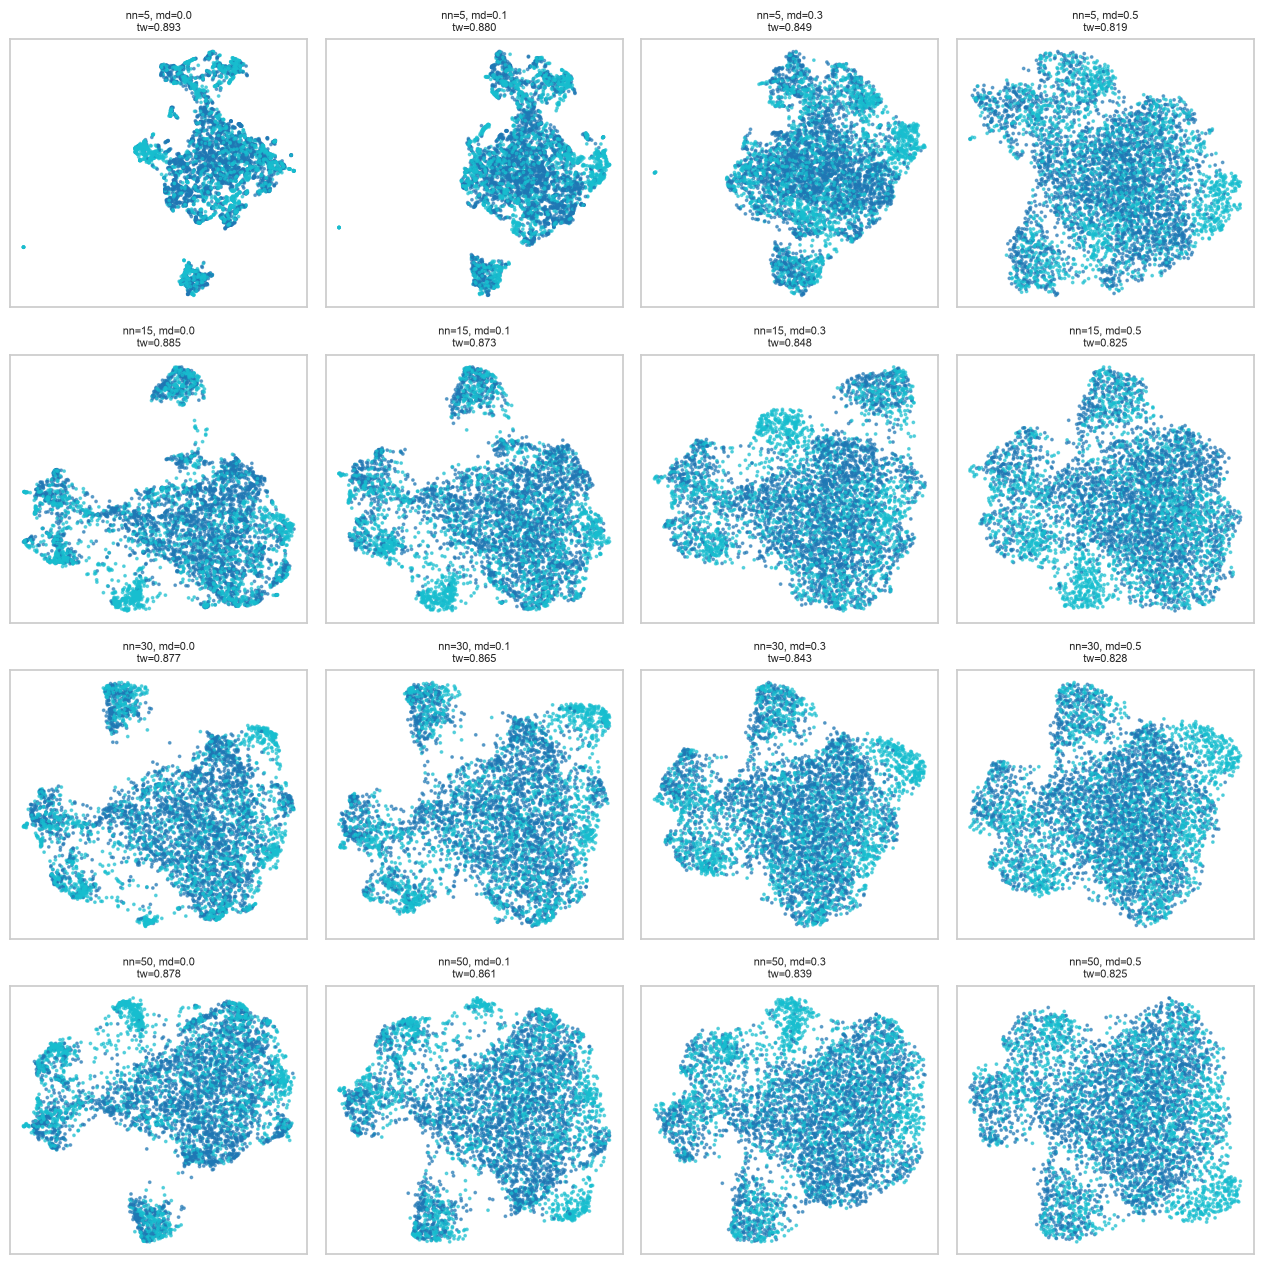

In [16]:
def plot_param_sweep_grid(results, param_labels, n_cols=4, color_by=None):
    n = len(results)
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows), squeeze=False)
    axes = axes.ravel()
    for ax, res, label in zip(axes, results, param_labels):
        emb = res["embedding"]
        # Plot the embedding colored by the specified variable (e.g., clinical group)
        ax.scatter(emb[:, 0], emb[:, 1], c=color_by, cmap="tab10", s=3, alpha=0.6)
        ax.set_title(f"{label}\ntw={res['trustworthiness']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

labels = [f"nn={r['n_neighbors']}, md={r['min_dist']}" for r in umap_results]
plot_param_sweep_grid(umap_results, labels, color_by=clinical_group[sweep_idx] == "CMV+")

In [17]:
# --- UMAP on the same fixed subsample ---
reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0,
    random_state=RANDOM_SEED,
    low_memory=True,
)
X_umap_cmp = reducer.fit_transform(X_pca)

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## t-SNE parameter sweep (perplexity)

Unlike the exploratory UMAP/t-SNE runs above (which use the full ~40k-cell dataset to maximize sensitivity for the rare adaptive-NK subset in the marker-overlay plots), everything below is computed on the fixed 5,000-cell subsample (`X_pca_sweep`) already used for the UMAP sweep. t-SNE's runtime scales badly with the number of points even with Barnes-Hut, so sweeping perplexity on the full data would be far too slow — the subsample keeps this fast while staying representative (same donors, same balancing as the full dataset).

`perplexity` roughly sets how many neighbors t-SNE tries to preserve for each point (similar in spirit to UMAP's `n_neighbors`, though the underlying mechanism — a probability distribution over neighbors vs. an explicit fuzzy graph — is different):
- **Low perplexity** (e.g. 5) → optimizes only very local neighborhoods → tends to fragment the data into many small, tight islands and can create fake substructure that isn't really there.
- **High perplexity** (e.g. 100) → tries to preserve much larger neighborhoods → smoother, more "global-looking" embedding, but risks merging genuinely distinct populations together and losing fine local structure.
- The commonly recommended range is roughly 5–50; results are usually not too sensitive within that range for well-sampled data, and it's the extremes outside it where you see clear degradation.

In [18]:
tsne_param_grid = [{"perplexity": p} for p in [5, 15, 30, 50, 100]]

tsne_sweep_results = []
for params in tsne_param_grid:
    tsne_sweep = TSNE(
        n_components=2,
        init="pca",
        random_state=RANDOM_SEED,
        n_jobs=6,
        max_iter=750,
        method="barnes_hut",
        **params,
    )
    embedding = tsne_sweep.fit_transform(X_pca_sweep)
    score_tw = trustworthiness(X_pca_sweep, embedding, n_neighbors=15)
    score_knn = knn_preservation(X_pca_sweep, embedding, k=15)
    tsne_sweep_results.append({**params, "trustworthiness": score_tw, "knn_preservation": score_knn,
                                "embedding": embedding})

tsne_sweep_df = pd.DataFrame(tsne_sweep_results).drop(columns="embedding")
tsne_sweep_df.sort_values("trustworthiness", ascending=False)

,perplexity,trustworthiness,knn_preservation
3,50,0.924053,0.219053
4,100,0.922786,0.212800
2,30,0.921083,0.221013
1,15,0.917388,0.212853
0,5,0.896676,0.185693


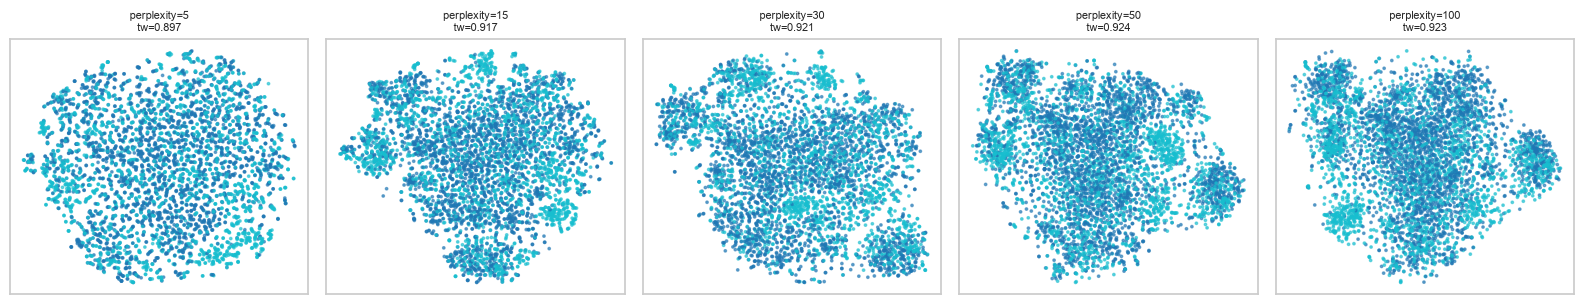

In [19]:
tsne_sweep_labels = [f"perplexity={r['perplexity']}" for r in tsne_sweep_results]
plot_param_sweep_grid(
    tsne_sweep_results, tsne_sweep_labels,
    n_cols=len(tsne_param_grid),
    color_by=clinical_group[sweep_idx] == "CMV+",
)

## Selecting final parameters and building a fair three-way comparison

To compare PCA, t-SNE and UMAP against each other, all three need to be evaluated on the *same* set of cells with *systematically chosen* parameters (not hand-picked from eyeballing a grid). We take each method's best setting from its own sweep — highest trustworthiness on the fixed subsample — and recompute all three embeddings on that same 5,000-cell subsample.

In [20]:
best_tsne_perplexity = int(
    tsne_sweep_df.sort_values("trustworthiness", ascending=False).iloc[0]["perplexity"]
)
best_umap_row = umap_results_df.sort_values("trustworthiness", ascending=False).iloc[0]
best_umap_n_neighbors = int(best_umap_row["n_neighbors"])
best_umap_min_dist = float(best_umap_row["min_dist"])

print(f"Selected t-SNE perplexity: {best_tsne_perplexity}")
print(f"Selected UMAP params: n_neighbors={best_umap_n_neighbors}, min_dist={best_umap_min_dist}")

Selected t-SNE perplexity: 50
Selected UMAP params: n_neighbors=5, min_dist=0.0


In [21]:
# --- Final embeddings, all on the same fixed 5,000-cell subsample (X_pca_sweep) ---
X_pca_final = X_pca_sweep[:, :2]  # first two PCs of the same subsample

tsne_final = TSNE(
    n_components=2, perplexity=best_tsne_perplexity, init="pca",
    random_state=RANDOM_SEED, n_jobs=6, max_iter=750, method="barnes_hut",
)
X_tsne_final = tsne_final.fit_transform(X_pca_sweep)

umap_final = umap.UMAP(
    n_neighbors=best_umap_n_neighbors, min_dist=best_umap_min_dist,
    random_state=RANDOM_SEED, low_memory=True,
)
X_umap_final = umap_final.fit_transform(X_pca_sweep)

embeddings_final = {"PCA": X_pca_final, "t-SNE": X_tsne_final, "UMAP": X_umap_final}

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Users\marie\AppData\Local\Temp\ipykernel_15100\1471979516.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


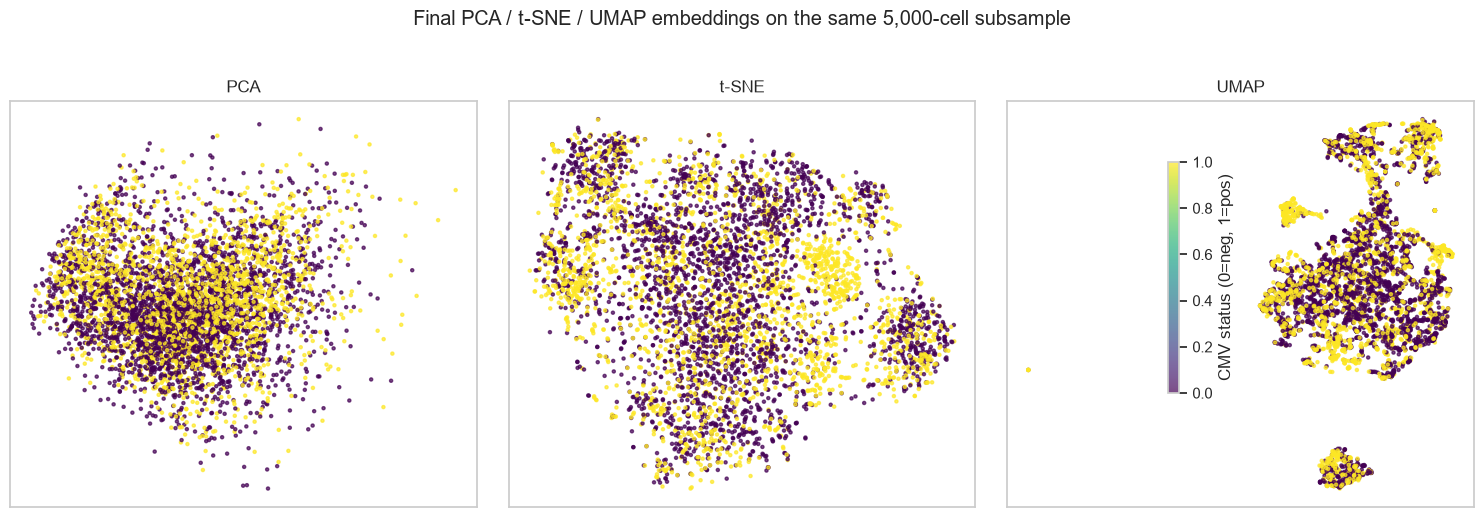

In [22]:
color_vals = (clinical_group[sweep_idx] == "CMV+").astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, emb) in zip(axes, embeddings_final.items()):
    sc_plot = ax.scatter(emb[:, 0], emb[:, 1], c=color_vals, cmap="viridis", s=5, alpha=0.7)
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc_plot, ax=axes, shrink=0.6, label="CMV status (0=neg, 1=pos)")
fig.suptitle("Final PCA / t-SNE / UMAP embeddings on the same 5,000-cell subsample", y=1.03)
plt.tight_layout()
plt.show()

## Quantitative comparison of the three visualizations

Two related, standard measures for how well a low-D embedding preserves high-D neighborhood structure:
- **Trustworthiness** — checks whether points that appear close in the low-D embedding were actually close in the high-D space; penalizes "false neighbors" introduced by the projection. Standard, well-established (`sklearn.manifold.trustworthiness`), scale 0–1.
- **kNN-preservation** (defined above, in the UMAP-sweep cell) — the plain fraction of each point's k nearest neighbors that are shared between the high-D and low-D representations. Less standard in the literature but more intuitive, and — importantly for what follows — symmetric.

Other measures that could be used but weren't chosen here: continuity (the mirror image of trustworthiness — penalizes *missing* true neighbors instead of false ones), Shepard diagrams / correlation between pairwise distances in high-D vs. low-D (captures global/metric structure rather than just local neighborhoods), and cluster-agreement scores such as silhouette, ARI or NMI computed against the known clinical labels or the Leiden clusters from the downstream clustering notebook.

For the **pairwise comparison between the three 2D embeddings themselves** (as opposed to each embedding vs. the high-D reference), we use kNN-preservation rather than trustworthiness: trustworthiness is explicitly asymmetric (it requires designating one side as "ground truth"), which doesn't make sense when comparing two projections that are both approximations, with neither being the reference.

In [23]:
# --- Each embedding vs. the shared high-D reference it was derived from ---
reference_space = X_pca_sweep

quality_rows = []
for name, emb in embeddings_final.items():
    quality_rows.append({
        "embedding": name,
        "trustworthiness": trustworthiness(reference_space, emb, n_neighbors=15),
        "knn_preservation": knn_preservation(reference_space, emb, k=15),
    })

quality_df = pd.DataFrame(quality_rows).set_index("embedding")
quality_df

,trustworthiness,knn_preservation
embedding,,
PCA,0.725188,0.031293
t-SNE,0.924053,0.219053
UMAP,0.888534,0.168467


,pair,knn_preservation
0,PCA vs t-SNE,0.030107
1,PCA vs UMAP,0.024360
2,t-SNE vs UMAP,0.218027


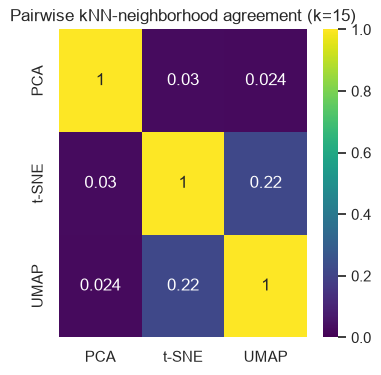

In [24]:
# --- Pairwise comparison between the three 2D embeddings, for all pairs ---
from itertools import combinations

pair_matrix = pd.DataFrame(
    np.eye(len(embeddings_final)), index=embeddings_final.keys(), columns=embeddings_final.keys()
)
pair_rows = []
for name_a, name_b in combinations(embeddings_final.keys(), 2):
    score = knn_preservation(embeddings_final[name_a], embeddings_final[name_b], k=15)
    pair_matrix.loc[name_a, name_b] = score
    pair_matrix.loc[name_b, name_a] = score
    pair_rows.append({"pair": f"{name_a} vs {name_b}", "knn_preservation": score})

pairwise_df = pd.DataFrame(pair_rows)
display(pairwise_df)

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(pair_matrix, annot=True, vmin=0, vmax=1, cmap="viridis", ax=ax)
ax.set_title("Pairwise kNN-neighborhood agreement (k=15)")
plt.show()

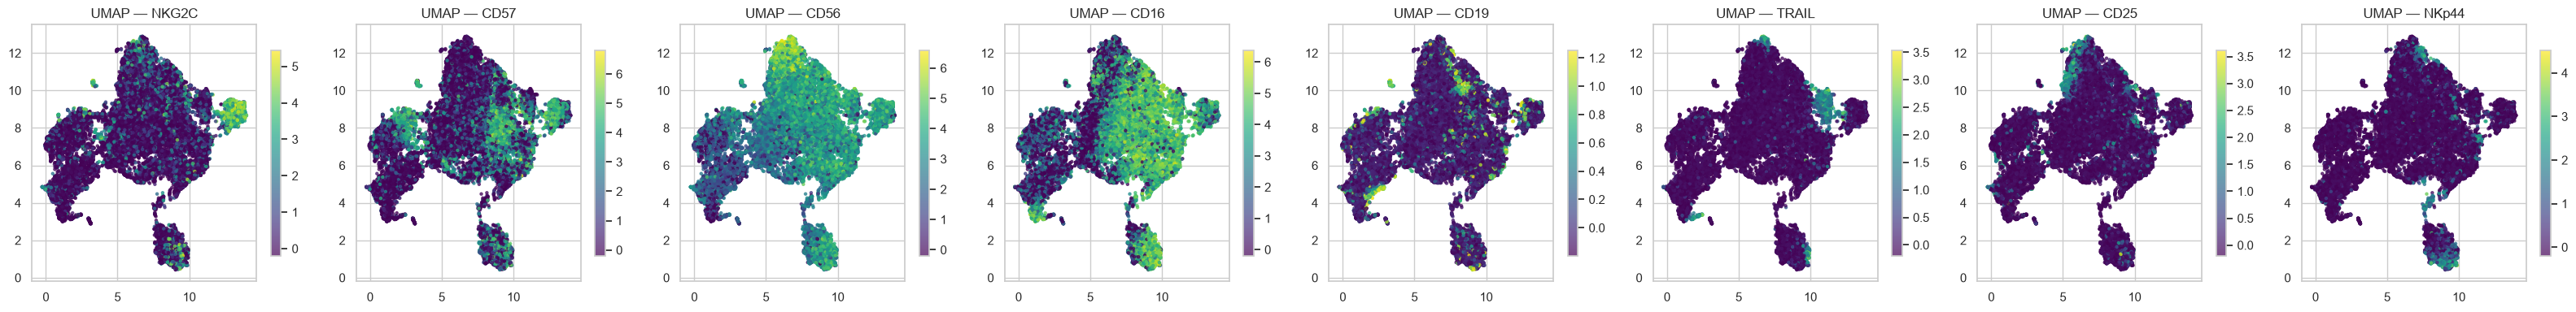

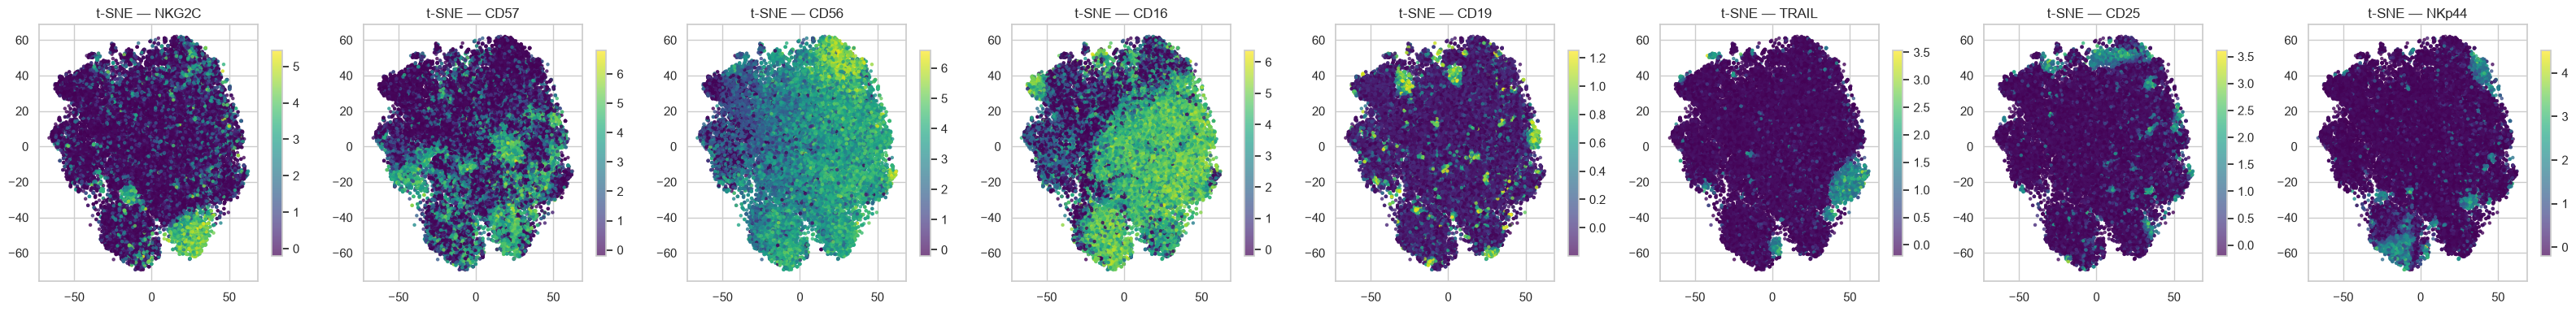

In [25]:
# --- Marker-overlay plots: check for the rare CMV-associated subset directly ---
# Instead of only coloring by CMV/donor, color the embedding by continuous marker
# expression — a rare subset may only show up this way, not as a global split.
diagnostic_markers_for_overlay = ["NKG2C", "CD57", "CD56", "CD16", "CD19", "TRAIL", "CD25", "NKp44"]

# Pull the arcsinh-transformed (unscaled) marker values for the same subsampled cells,
# so color scales stay interpretable (rather than z-scored units).
marker_values_cmp = nk_transformed[diagnostic_markers_for_overlay]

def plot_embedding_by_markers(coords, title_prefix):
    fig, axes = plt.subplots(
        1,
        len(diagnostic_markers_for_overlay),
        figsize=(4 * len(diagnostic_markers_for_overlay), 4),
        squeeze=False,
    )
    axes = axes.ravel()
    for ax, marker in zip(axes, diagnostic_markers_for_overlay):
        sc_plot = ax.scatter(
            coords[:, 0], coords[:, 1],
            c=marker_values_cmp[marker].to_numpy(), cmap="viridis", s=5, alpha=0.7,
        )
        ax.set_title(f"{title_prefix} — {marker}")
        fig.colorbar(sc_plot, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

plot_embedding_by_markers(X_umap_cmp, "UMAP")
plot_embedding_by_markers(np.asarray(X_tsne_cmp), "t-SNE")

KeyError: 'CD3'

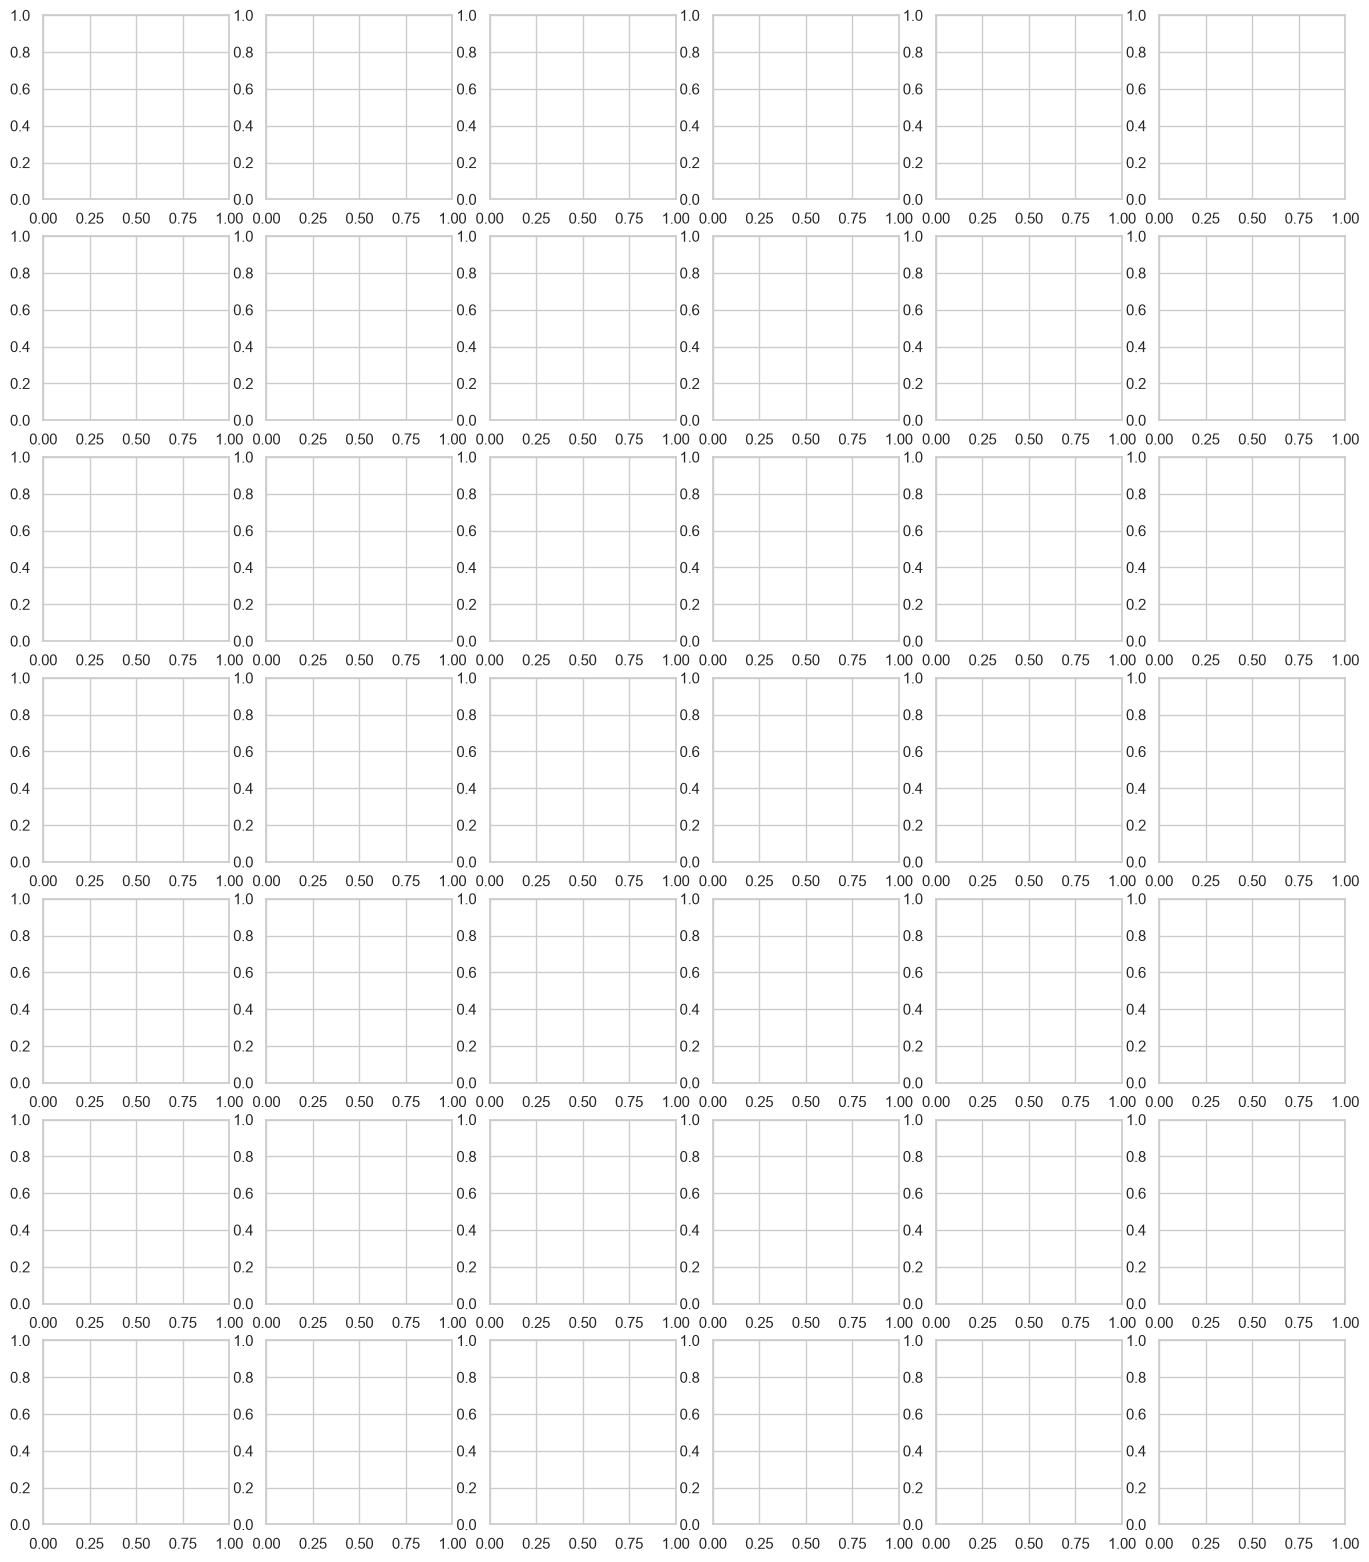

In [26]:
def plot_embedding_by_markers(coords, marker_values, markers, title_prefix,
                               n_cols=6, point_size=3, alpha=0.6,
                               clip_percentiles=(1, 99)):
    """
    coords: (n_cells, 2) array — embedding coordinates (PCA/t-SNE/UMAP)
    marker_values: DataFrame with one column per marker, same row order as coords
    markers: list of marker names to plot (can be all analysis_markers)
    """
    n_markers = len(markers)
    n_rows = math.ceil(n_markers / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.8 * n_cols, 2.8 * n_rows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, marker in zip(axes, markers):
        values = marker_values[marker].to_numpy()
        vmin, vmax = np.percentile(values, clip_percentiles)

        sc_plot = ax.scatter(
            coords[:, 0], coords[:, 1],
            c=values, cmap="viridis", s=point_size, alpha=alpha,
            vmin=vmin, vmax=vmax,
        )
        ax.set_title(marker, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(sc_plot, ax=ax, shrink=0.7, pad=0.02)

    # Hide any unused axes (when n_markers doesn't divide evenly into the grid)
    for ax in axes[n_markers:]:
        ax.axis("off")

    fig.suptitle(title_prefix, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Plot every analysis marker for both embeddings.
plot_embedding_by_markers(X_umap_cmp, marker_values_cmp, analysis_markers, "UMAP")
plot_embedding_by_markers(np.asarray(X_tsne_cmp), marker_values_cmp, analysis_markers, "t-SNE")
markers_by_variance = marker_variance.sort_values(ascending=False).index.tolist()

In [27]:
plot_embedding_by_markers(
    coords=X_umap_cmp,
    marker_values=marker_values_cmp[markers_by_variance],
    markers=markers_by_variance,
    title_prefix="UMAP — markers sorted by variance",
)

NameError: name 'markers_by_variance' is not defined

In [ ]:
# --- Determine positivity thresholds for NKG2C and CD57 ---
# Simple, transparent approach: fit a 2-component Gaussian mixture per marker on the
# full data and use the crossover point between the two components as the threshold.
from sklearn.mixture import GaussianMixture

nk_full_transformed = arcsinh_transform(nk_full_raw, analysis_markers, ARCSINH_COFACTOR)

def estimate_positive_threshold(values, random_state=RANDOM_SEED):
    values = values.to_numpy().reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=random_state).fit(values)
    means = gmm.means_.ravel()
    neg_component, pos_component = np.argsort(means)
    # Scan a fine grid between the two means; take the point where posterior
    # probability of the positive component first exceeds 0.5.
    grid = np.linspace(means[neg_component], means[pos_component], 1000).reshape(-1, 1)
    posterior_pos = gmm.predict_proba(grid)[:, pos_component]
    crossover_idx = np.argmax(posterior_pos > 0.5)
    return grid[crossover_idx, 0]

thresholds = {
    marker: estimate_positive_threshold(nk_full_transformed[marker])
    for marker in ["NKG2C", "CD57"]
}
print(thresholds)

{'NKG2C': np.float64(0.0858454660137142), 'CD57': np.float64(0.08457670597770588)}


In [ ]:
# --- Flag double-positive (adaptive NK) cells in both datasets using the same thresholds ---
def flag_double_positive(frame, thresholds):
    return (
        (frame["NKG2C"] > thresholds["NKG2C"]) &
        (frame["CD57"] > thresholds["CD57"])
    )

nk_full_transformed["adaptive_nk"] = flag_double_positive(nk_full_transformed, thresholds)
nk_transformed["adaptive_nk"] = flag_double_positive(nk_transformed, thresholds)  # your 2000-3000/donor subsample

# --- Per-donor fraction: full data vs. subsample ---
full_fraction = nk_full_transformed.groupby("sample_id")["adaptive_nk"].mean().rename("full_fraction")
subsample_fraction = nk_transformed.groupby("sample_id")["adaptive_nk"].mean().rename("subsample_fraction")
full_counts = nk_full_transformed.groupby("sample_id")["adaptive_nk"].sum().rename("full_count")
subsample_counts = nk_transformed.groupby("sample_id")["adaptive_nk"].sum().rename("subsample_count")

comparison = pd.concat(
    [full_fraction, subsample_fraction, full_counts, subsample_counts], axis=1
).join(labels.set_index("sample_id")[["clinical_group"]])

comparison["subsample_n_cells"] = nk_transformed.groupby("sample_id").size()
comparison

,full_fraction,subsample_fraction,full_count,subsample_count,clinical_group,subsample_n_cells
sample_id,,,,,,
a_001,0.199367,0.1825,1260,365,CMV+,2000
a_002,0.415523,0.3935,6569,787,CMV+,2000
a_003,0.175468,0.1760,2007,352,CMV−,2000
a_004,0.100785,0.0985,1758,197,CMV−,2000
a_005,0.290494,0.3120,7328,624,CMV+,2000
a_006,0.119958,0.1220,678,244,CMV−,2000
a_007,0.178124,0.1720,1749,344,CMV+,2000
a_009,0.117837,0.1205,2404,241,CMV−,2000
a_010,0.076661,0.0725,697,145,CMV−,2000


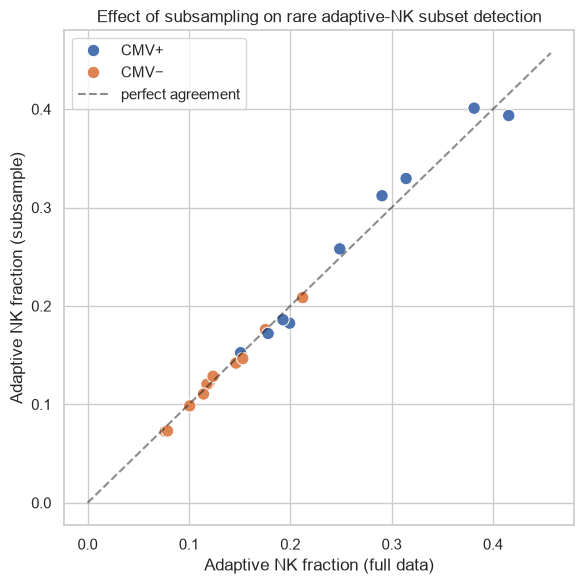

,full_fraction,subsample_fraction,full_count,subsample_count,clinical_group,subsample_n_cells
sample_id,,,,,,


In [ ]:
# --- Visualize: does subsampling distort the adaptive-NK fraction per donor? ---
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=comparison, x="full_fraction", y="subsample_fraction",
    hue="clinical_group", s=80, ax=ax,
)
lims = [0, max(comparison["full_fraction"].max(), comparison["subsample_fraction"].max()) * 1.1]
ax.plot(lims, lims, "k--", alpha=0.5, label="perfect agreement")
ax.set(xlabel="Adaptive NK fraction (full data)", ylabel="Adaptive NK fraction (subsample)",
       title="Effect of subsampling on rare adaptive-NK subset detection")
ax.legend()
plt.tight_layout()
plt.show()

# Flag donors where the subsample count is worryingly low (rule of thumb: <10 cells)
comparison[comparison["subsample_count"] < 10]

If points fall close to the diagonal, your 2,000–3,000 cells/donor subsample is representative enough for this particular subset in this dataset. If some donors show a subsample fraction of exactly 0 while the full data shows a nonzero (even if small) fraction, that's the sampling-variance effect from before made concrete — worth checking comparison[comparison["subsample_count"] < 10] specifically, since those are the donors where any downstream conclusion about "this donor doesn't have the adaptive NK subset" is unreliable and really reflects a full-data check being necessary, not the subsample.

In [ ]:
# from sklearn.decomposition import KernelPCA

# kpca = KernelPCA(
#     n_components=2,
#     kernel="rbf",           # radial basis function — most common nonlinear choice
#     gamma=0.03,             # kernel width — see below
#     fit_inverse_transform=True,  # needed to compute reconstruction error later
#     random_state=RANDOM_SEED,
# )
# X_kpca = kpca.fit_transform(X)  # X = your arcsinh + z-scored matrix

In [ ]:
# X_kpca_reconstructed = kpca.inverse_transform(X_kpca)
# kpca_mse = np.mean((X - X_kpca_reconstructed) ** 2)
# print(f"Kernel PCA (gamma={kpca.gamma}) reconstruction MSE: {kpca_mse:.4f}")

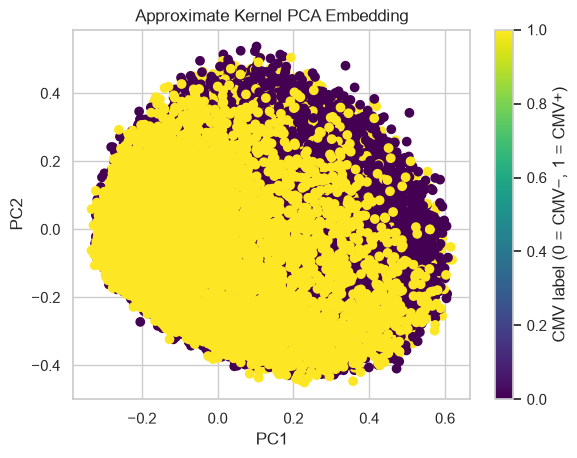

In [ ]:
from sklearn.kernel_approximation import Nystroem
from sklearn.decomposition import PCA

# n_components here = number of landmark points used to approximate the kernel,
# NOT the number of output dimensions — keep this modest (100-500) for speed.
N_LANDMARKS = 300

nystroem = Nystroem(
    kernel="rbf",
    gamma=0.03,
    n_components=N_LANDMARKS,
    random_state=RANDOM_SEED,
)
X_nystroem = nystroem.fit_transform(X)  # shape: (n_cells, N_LANDMARKS) — still all 40,000 cells

# Now do ordinary (fast) linear PCA on the approximated kernel feature space
pca_approx = PCA(n_components=2, random_state=RANDOM_SEED)
X_kpca_approx = pca_approx.fit_transform(X_nystroem)
# Use labels aligned with the cells used to create X_kpca_approx.
cell_labels = nk_scaled["label"].to_numpy()

plt.scatter(
    X_kpca_approx[:, 0],
    X_kpca_approx[:, 1],
    c=cell_labels,
    cmap="viridis",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Approximate Kernel PCA Embedding")
plt.colorbar(label="CMV label (0 = CMV−, 1 = CMV+)")
plt.show()

The gamma parameter (for the RBF kernel) controls how "local" the similarity measure is — conceptually similar in spirit to t-SNE's perplexity or UMAP's n_neighbors, even though the mechanism is different:

Small gamma → the kernel has a wide reach, treats distant points as still somewhat similar → smoother, more global structure, behaves closer to linear PCA.
Large gamma → only very nearby points count as similar → very local, can pick up fine nonlinear structure but is prone to overfitting noise and fragmenting into many tiny groups.

Since you don't have strong priors on gamma, sweep a log-spaced range (e.g. [0.001, 0.01, 0.03, 0.1, 0.3, 1.0]) and look at both the resulting scatter and the reconstruction error (next section) to pick a reasonable value.

Reduce gamma-sweep granularity first, on a small subsample (e.g. 2,000–5,000 cells with exact KernelPCA) to find a reasonable gamma range, then only run the expensive full-data version once with that narrowed-down value — you don't need to sweep gamma at full scale.

Lower N_LANDMARKS in the Nystroem approach (e.g. 100 instead of 300) trades approximation quality for speed — worth checking if results look meaningfully different at 100 vs 300 vs 500 before committing to a larger value.

Feed it PCA-reduced input (e.g. X_pca[:, :20] instead of the raw 37-dim X) rather than the full marker matrix — kernel computation cost scales with the input dimensionality too, and you likely don't lose meaningful information by kernelizing the already-PCA-reduced representation.

Avoid fit_inverse_transform=True unless you specifically need the reconstruction-error comparison from before — fitting the inverse mapping is an extra (nontrivial) regression step on top of the kernel computation itself.

In [ ]:
# # --- Persist all three embeddings + metadata for the next notebook (e.g. clustering) ---
# embedding_export = pd.DataFrame({
#     "sample_id": sample_ids_cmp,
#     "clinical_group": clinical_group_cmp,
#     "PC1": X_pca_cmp[:, 0], "PC2": X_pca_cmp[:, 1],
#     "tsne1": X_tsne_cmp[:, 0], "tsne2": X_tsne_cmp[:, 1],
#     "umap1": X_umap_cmp[:, 0], "umap2": X_umap_cmp[:, 1],
# })
# embedding_export.to_parquet(ARTIFACT_DIR / "embeddings_comparison_subsample.parquet", index=False)

# # Also persist the full-data PCA (all 40k cells) separately, for anything downstream
# # that doesn't need the fixed subsample (e.g. clustering on the full dataset)
# np.save(ARTIFACT_DIR / "X_pca_full.npy", X_pca)
# nk_transformed[["sample_id", "label", "clinical_group"]].to_parquet(
#     ARTIFACT_DIR / "nk_transformed_meta.parquet", index=False
# )